# Making a new domain: `CStarSpecBuilder`

This notebook demonstrates how to create a new domain and run a ROMS simulation using C-SON Forge.


## Setup

First, import the necessary modules and define the domain configuration parameters.


In [1]:
%load_ext autoreload
%autoreload 2

import cson_forge
import cstar.execution.handler as handler
import time
from datetime import datetime 

ERROR 1: PROJ: proj_create_from_database: Open of /home/x-awyatt1/.local/share/mamba/envs/cson-forge-v0/share/proj failed


In [2]:
description_o= "Pacific 1/2 deg (nested)"
model_name= "cson_roms-marbl_v0.1"
grid_name_o= "PAC-0p5_deg"
start_time_o= "2010-01-01"
end_time= "2010-01-10" ## note that the end_time variable is the same for all 3 grids
grid_kwargs_o=dict(
    nx= 208,
    ny= 192,
    size_x= 7300,
    size_y= 11100,
    center_lon= -165,
    center_lat= 40,
    rot= -90,
    N= 10,
    theta_s= 6.0,
    theta_b= 3.0,
    hc= 250.0,
)
boundaries_o= dict(
    south= True,
    east= True,
    north= True,
    west= True,
)
partitioning_o= dict(
    n_procs_x= 16,
    n_procs_y= 16
)
_child_grid_name_o= "NEP-p25_deg"

In [3]:
description_m= "Northeast Pacific 1/4 deg (nested)"
model_name= "cson_roms-marbl_v0.1"
grid_name_m= "NEP-p25_deg"
start_time_m= "2010-01-02"
end_time= "2010-01-10"  ## note that the end_time variable is the same for all 3 grids
grid_kwargs_m=dict(
    nx= 208,
    ny= 192,
    size_x= 3650,
    size_y= 5550,
    center_lon= -140,
    center_lat= 40,
    rot= 43,
    N= 10,
    theta_s= 6.0,
    theta_b= 3.0,
    hc= 250.0,
    metadata=dict(
        prefix= "child",
        period= 3600.0,
        include_bgc= True,
        )
)
boundaries_m= dict(
    south= True,
    east= False,
    north= True,
    west= True,
)
partitioning_m=dict(
    n_procs_x= 16,
    n_procs_y= 16,
)
_parent_grid_name_m= "PAC-0p5_deg",
_child_grid_name_m= "GoA-p10_deg",


In [4]:
description_i= "Gulf of Alaska 1/10 deg (nested)"
model_name= "cson_roms-marbl_v0.1"
grid_name_i= "GoA-p10_deg"
start_time_i= "2010-01-03"
end_time= "2010-01-10"  ## note that the end_time variable is the same for all 3 grids
grid_kwargs_i=dict(
    nx= 208,
    ny= 192,
    size_x= 1460,
    size_y= 2350,
    center_lon= -139.5,
    center_lat= 53,
    rot= 41,
    N= 10,
    theta_s= 6.0,
    theta_b= 3.0,
    hc= 250.0,
    metadata=dict(
        prefix= "child",
        period= 3600.0,
        include_bgc= True,
    )
)

boundaries_i=dict(
    south= True,
    east= False,
    north= True,
    west= True,
)
partitioning_i=dict(
    n_procs_x= 16,
    n_procs_y= 16,
)
_parent_grid_name= "NEP-p25_deg"

## Initialize CstarSpecBuilder

Create a `CstarSpecBuilder` instance with the domain configuration. This initializes the PRECONFIG stage, creating the grid object and blueprint structure.


In [5]:
ocn_outer = cson_forge.CstarSpecBuilder(
    description=description_o,
    model_name=model_name,
    grid_name=grid_name_o,
    grid_kwargs=grid_kwargs_o,
    grid_kwargs_child=grid_kwargs_m,
    open_boundaries=boundaries_o,    
    start_time=start_time_o,
    end_time=end_time,
    partitioning=partitioning_o,
)

ocn_middle = cson_forge.CstarSpecBuilder(
    description=description_m,
    model_name=model_name,
    grid_name=grid_name_m,
    grid_kwargs=grid_kwargs_m,
    grid_kwargs_parent=grid_kwargs_o,
    grid_kwargs_child=grid_kwargs_i,
    open_boundaries=boundaries_m,    
    start_time=start_time_m,
    end_time=end_time,
    partitioning=partitioning_m,
)

ocn_inner = cson_forge.CstarSpecBuilder(
    description=description_i,
    model_name=model_name,
    grid_name=grid_name_i,
    grid_kwargs=grid_kwargs_i,
    grid_kwargs_parent=grid_kwargs_m,
    open_boundaries=boundaries_m,    
    start_time=start_time_i,
    end_time=end_time,
    partitioning=partitioning_i,
)

### Visualize the grid

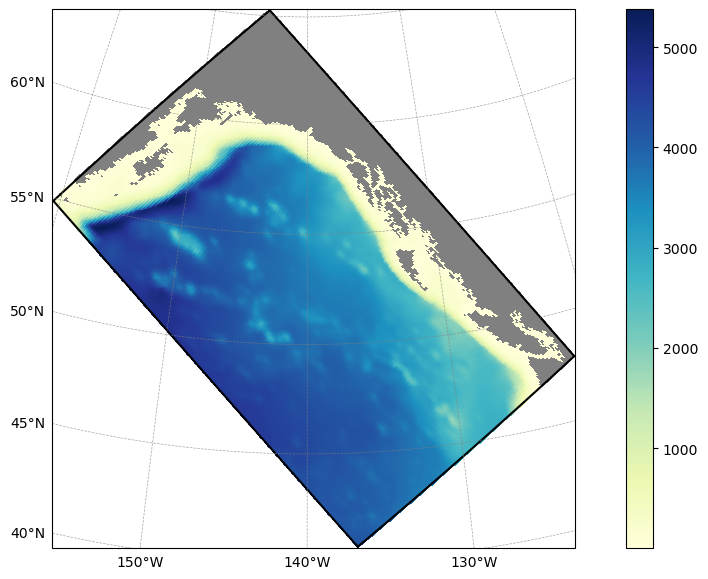

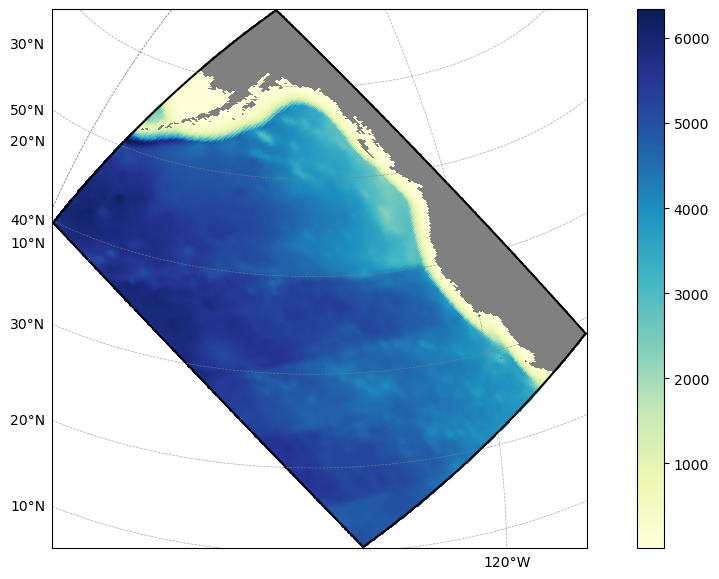

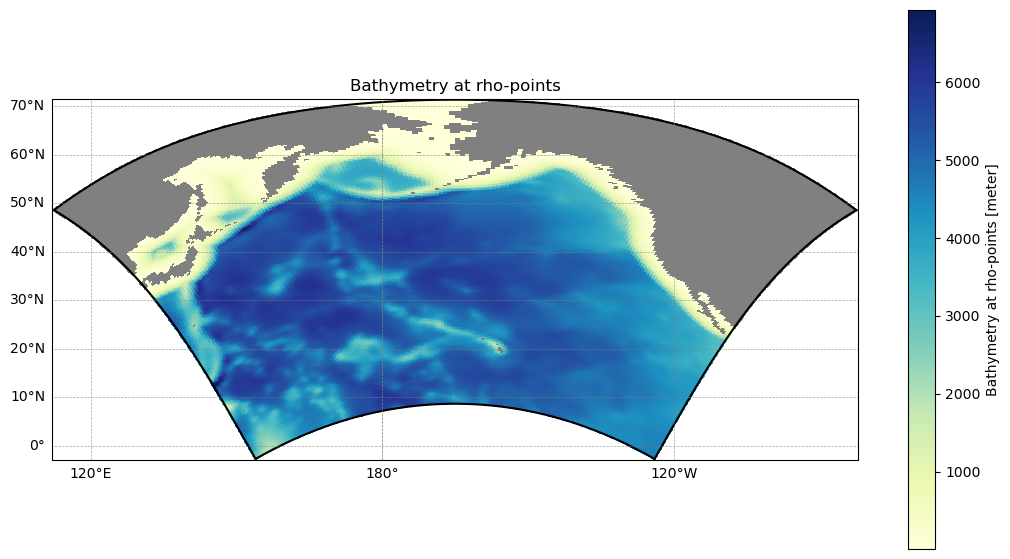

In [6]:
ocn_inner.grid.plot()
ocn_middle.grid.plot()
ocn_outer.grid.plot()

## Prepare Source Data

Ensure that all required source datasets (GLORYS, UNIFIED, SRTM15, etc.) are staged locally. This downloads and prepares the data needed for input generation.


In [7]:
# ensure that source data is staged locally
for ocn in [ocn_outer,ocn_middle,ocn_inner]:
    ocn.ensure_source_data()

✔️  Using existing GLORYS_GLOBAL file for 2009-12-31: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20091231.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-01: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100101.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-02: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100102.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-03: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100103.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-04: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100104.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-05: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100105.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-06: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100106.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-07: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100107.nc
✔️  Using existing GLORYS_GLOBAL file for 2010-01-08: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20100108.nc
✔️  Using existing 

## Generate Input Files

Generate all model input files (grid, initial conditions, forcing) from the source data. This completes the POSTCONFIG stage and updates the blueprint with actual file paths.

The system will look for an existing blueprint and, if a match is found, it will use that data unless the user sets `clobber=True` to force re-generating the data. 


In [9]:
# prepare model input

ocn_outer.generate_inputs(clobber=True) # setting clobber=True will overwrite existing files
print('~~~done outer~~~\n')

ocn_middle.generate_inputs(clobber=True) # setting clobber=True will overwrite existing files
print('~~~done middle~~~\n')

ocn_inner.generate_inputs(clobber=True) # setting clobber=True will overwrite existing files
print('~~~done inner~~~\n')

/anvil/projects/x-ees250129/x-awyatt1/cson-forge/cson_forge/_core.py:1421: UserWarning: Blueprint field 'code' does not match POSTCONFIG blueprint from file. At compile_time: At compile_time.location: Value mismatch: current=placeholder://compile_time, file=/anvil/projects/x-ees250129/x-awyatt1/cson-forge/cson_forge/catalog/builds/cson_roms-marbl_v0.1_PAC-0p5_deg_256procs/compile-time
  if not self._file_blueprint_data_match(partition_files=partition_files) or clobber:


⚠️  Clobber=True: removing 12 existing .nc files in /anvil/projects/x-ees250129/cson-forge-data/x-awyatt1/input-data/cson_roms-marbl_v0.1_PAC-0p5_deg_256procs...

▶️  [1/8] Writing ROMS grid...

▶️  [2/8] Generating initial conditions...


2026-04-08 21:58:09,181 [WARNING] - utils.py:109 - Optional variables missing (but not critical): ['Lig', 'DIC_ALT_CO2', 'Alk_ALT_CO2']


[########################################] | 100% Completed | 80.13 s

▶️  [3/8] Generating surface forcing...
[########################################] | 100% Completed | 730.18 ms
[########################################] | 100% Completed | 88.47 s


2026-04-08 22:03:33,660 [WARNING] - utils.py:109 - Optional variables missing (but not critical): ['pco2_air_alt']


...

/anvil/projects/x-ees250129/x-awyatt1/cson-forge/cson_forge/input_data.py:299: UserWarning: Failed to save surface forcing YAML to /anvil/projects/x-ees250129/x-awyatt1/cson-forge/cson_forge/catalog/blueprints/RCAC_anvil/cson_roms-marbl_v0.1_GoA-p10_deg_256procs/_forcing.surface-bgc.yml: ('cannot represent an object', <xarray.Dataset> Size: 4MB
Dimensions:       (eta_rho: 194, xi_rho: 210, xi_u: 209, eta_v: 193,
                   eta_coarse: 98, xi_coarse: 106, s_rho: 10, s_w: 11)
Coordinates:
    lat_rho       (eta_rho, xi_rho) float64 326kB 10.63 10.72 ... 68.83 68.94
    lon_rho       (eta_rho, xi_rho) float64 326kB 224.2 224.4 ... 208.1 208.3
    lat_u         (eta_rho, xi_u) float64 324kB 10.68 10.77 ... 68.77 68.88
    lon_u         (eta_rho, xi_u) float64 324kB 224.3 224.4 ... 207.9 208.2
    lat_v         (eta_v, xi_rho) float64 324kB 10.73 10.82 ... 68.75 68.86
    lon_v         (eta_v, xi_rho) float64 324kB 224.2 224.3 ... 208.3 208.6
    lat_coarse    (eta_coarse, xi_coarse

[########################################] | 100% Completed | 4.48 sms

▶️  [8/8] Generating river forcing...


/anvil/projects/x-ees250129/x-awyatt1/cson-forge/cson_forge/input_data.py:299: UserWarning: Failed to save tidal forcing YAML to /anvil/projects/x-ees250129/x-awyatt1/cson-forge/cson_forge/catalog/blueprints/RCAC_anvil/cson_roms-marbl_v0.1_GoA-p10_deg_256procs/_forcing.tidal.yml: ('cannot represent an object', <xarray.Dataset> Size: 4MB
Dimensions:       (eta_rho: 194, xi_rho: 210, xi_u: 209, eta_v: 193,
                   eta_coarse: 98, xi_coarse: 106, s_rho: 10, s_w: 11)
Coordinates:
    lat_rho       (eta_rho, xi_rho) float64 326kB 10.63 10.72 ... 68.83 68.94
    lon_rho       (eta_rho, xi_rho) float64 326kB 224.2 224.4 ... 208.1 208.3
    lat_u         (eta_rho, xi_u) float64 324kB 10.68 10.77 ... 68.77 68.88
    lon_u         (eta_rho, xi_u) float64 324kB 224.3 224.4 ... 207.9 208.2
    lat_v         (eta_v, xi_rho) float64 324kB 10.73 10.82 ... 68.75 68.86
    lon_v         (eta_v, xi_rho) float64 324kB 224.2 224.3 ... 208.3 208.6
    lat_coarse    (eta_coarse, xi_coarse) float6


✅ All input files generated.

~~~done inner~~~



/anvil/projects/x-ees250129/x-awyatt1/cson-forge/cson_forge/input_data.py:299: UserWarning: Failed to save river forcing YAML to /anvil/projects/x-ees250129/x-awyatt1/cson-forge/cson_forge/catalog/blueprints/RCAC_anvil/cson_roms-marbl_v0.1_GoA-p10_deg_256procs/_forcing.river.yml: ('cannot represent an object', <xarray.Dataset> Size: 4MB
Dimensions:       (eta_rho: 194, xi_rho: 210, xi_u: 209, eta_v: 193,
                   eta_coarse: 98, xi_coarse: 106, s_rho: 10, s_w: 11)
Coordinates:
    lat_rho       (eta_rho, xi_rho) float64 326kB 10.63 10.72 ... 68.83 68.94
    lon_rho       (eta_rho, xi_rho) float64 326kB 224.2 224.4 ... 208.1 208.3
    lat_u         (eta_rho, xi_u) float64 324kB 10.68 10.77 ... 68.77 68.88
    lon_u         (eta_rho, xi_u) float64 324kB 224.3 224.4 ... 207.9 208.2
    lat_v         (eta_v, xi_rho) float64 324kB 10.73 10.82 ... 68.75 68.86
    lon_v         (eta_v, xi_rho) float64 324kB 224.2 224.3 ... 208.3 208.6
    lat_coarse    (eta_coarse, xi_coarse) float6

## Access Generated Input Datasets

Input datasets are available on the `datasets` attribute of the `CstarSpecBuilder` after `generate_inputs()` has completed. The `datasets` dictionary only contains keys for fields that exist in the blueprint and have been successfully generated.

**Note:** Datasets are only available after `generate_inputs()` has run and populated the blueprint with actual file paths. If a key doesn't exist, it means that field wasn't generated or isn't in the blueprint.

In [10]:
for ocn in [ocn_outer,ocn_middle,ocn_inner]:
    for key in ocn.datasets.keys():
        print("-"*100)
        
        print(key)
        print(ocn.datasets[key])

----------------------------------------------------------------------------------------------------
grid
<xarray.Dataset> Size: 4MB
Dimensions:       (eta_rho: 194, xi_rho: 210, xi_u: 209, eta_v: 193,
                   eta_coarse: 98, xi_coarse: 106, s_rho: 10, s_w: 11)
Coordinates:
    lat_rho       (eta_rho, xi_rho) float64 326kB ...
    lon_rho       (eta_rho, xi_rho) float64 326kB ...
    lat_u         (eta_rho, xi_u) float64 324kB ...
    lon_u         (eta_rho, xi_u) float64 324kB ...
    lat_v         (eta_v, xi_rho) float64 324kB ...
    lon_v         (eta_v, xi_rho) float64 324kB ...
    lat_coarse    (eta_coarse, xi_coarse) float64 83kB ...
    lon_coarse    (eta_coarse, xi_coarse) float64 83kB ...
Dimensions without coordinates: eta_rho, xi_rho, xi_u, eta_v, eta_coarse,
                                xi_coarse, s_rho, s_w
Data variables: (12/15)
    angle         (eta_rho, xi_rho) float64 326kB ...
    f             (eta_rho, xi_rho) float64 326kB ...
    pm            (e

## Configure Build

Render the Jinja2 templates to generate compile-time and run-time configuration files (`.opt` files, `roms.in`, etc.). This prepares the BUILD stage.


In [13]:
# configure and build the model
for ocn in [ocn_outer,ocn_middle,ocn_inner]:
    ocn.configure_build(
        compile_time_settings={}, 
        run_time_settings={'roms.in': {'time_stepping': {'dt': 900}}}
    )

# 'roms.in': {'time_stepping': {'dt': 900}}

## Manual changes:
- change name and location of nesting file

In [ ]:
# ## NESTING FILE

# import shutil
# import os
# import re

# for key in [ocn_outer, ocn_middle]:
#     opt_file = str(key.compile_time_code_dir) + '/extract_data.opt'
#     with open(opt_file) as f:
#         text = f.read()
    
#     # get path of the nesting file from extract_data.opt
#     block = text.split('extract_file')[1]
#     old_path = ''.join(re.findall(r"'([^']*)'", block))
    
#     print("Old path:", old_path)
    
#     # Copy nesting file to short named directory
#     dst_dir = '/anvil/projects/x-ees250129/'
    
#     filename = os.path.basename(old_path)
#     new_name = filename.replace('cson_roms-marbl_v0.1_', '')
#     dst = os.path.join(dst_dir, new_name)
    
#     new_nc_file = shutil.copy(old_path, dst)
#     print("New nesting file path:", new_nc_file)
    
#     # replace filepath in extract_data.opt
#     with open(opt_file, 'r') as f:
#         lines = f.readlines()
    
#     new_lines = []
#     i = 0
    
#     while i < len(lines):
#         line = lines[i]
    
#         if 'extract_file' in line and '=' in line:
#             # skip original multi-line definition
#             i += 1
#             while i < len(lines) and ("'" in lines[i] or '//' in lines[i] or '&' in lines[i]):
#                 i += 1
    
#             # insert clean single-line version
#             new_lines.append(f"      character(len=512) :: extract_file = '{new_nc_file}'\n")
    
#         else:
#             new_lines.append(line)
#             i += 1
    
#     with open(opt_file, 'w') as f:
#         f.writelines(new_lines)

# print("done ammending files")